In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

if os.environ['GROQ_API_KEY']:
    print("API Key is Set!!!")
else:
    raise ValueError("API Key not loaded!!!")

API Key is Set!!!


In [12]:
from langchain_google_genai import ChatGoogleGenerativeAI
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash")
llm

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14', 'langchain-google-genai': '4.3.1'}}, output_version=None, profile={'name': 'Gemini 3.6 Flash', 'release_date': '2026-07-21', 'last_updated': '2026-07-21', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high'], 'reasoning_effort_default': 'medium'}, google_api_key=SecretStr('**********'), location=None, model='gemini-3.6-flash', temperature=None, client=<google.genai.client.Client object at 0x000001DB704F78C0>, defau

###  **Schema**

In [19]:
from pydantic import BaseModel, Field
from typing import Literal

class llm_schema(BaseModel):
    platform: Literal["Instagram", "X", "LinkedIn"] = Field(...,description="The platform for which caption should be generated")
    topic: str = Field(...,description="The topic of the post to generate")

In [20]:
llm_with_schema = llm.with_structured_output(llm_schema)

In [21]:
llm_with_schema.invoke("I want to generate a Instagram caption for Manali Trip")

llm_schema(platform='Instagram', topic='Manali Trip')

### State schema

In [23]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    input: str
    topic: str
    platform : str
    post: str

In [57]:
def decider_node(state: graph_schema) -> graph_schema:
    user_input = state['input']

    platform = llm_with_schema.invoke(user_input).platform
    topic = llm_with_schema.invoke(user_input).topic

    state['platform'] = platform
    state['topic'] = topic

    return state

In [58]:
def create_post_x(state: graph_schema) -> graph_schema:
    topic = state['topic']

    post = llm.invoke(f"Write a caption about {topic} for X platform. Keep the tone quick").content

    state['post'] = post

    return {'post' : post}

In [59]:
def create_post_linkedin(state: graph_schema) -> graph_schema:
    topic = state['topic']

    post = llm.invoke(f"Write a caption about {topic} for LinkedIn platform. Keep the tone professional").content

    state['post'] = post

    return {'post' : post}

In [60]:
def create_post_insta(state: graph_schema) -> graph_schema:
    topic = state['topic']

    post = llm.invoke(f"Write a caption about {topic} for Instagram platform. Keep the tone casual and engaging").content

    state['post'] = post
    
    return {'post' : post}

In [64]:
def condition(state: graph_schema)-> str:

    platform = state['platform']

    if platform == 'Instagram':
        return "create_post_insta"
    elif platform == 'X':
        return "create_post_x"
    elif platform =='LinkedIn':
        return "create_post_linkedin"
    else: 
        raise ValueError("invalid Category")

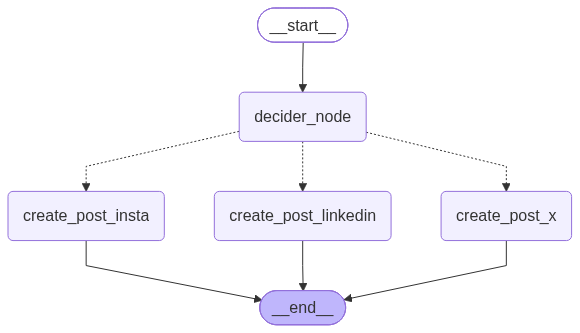

In [65]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

graph = StateGraph(graph_schema)

graph.add_node("decider_node", decider_node)
graph.add_node("create_post_x", create_post_x)
graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_linkedin", create_post_linkedin)

graph.add_edge(START, "decider_node")
graph.add_conditional_edges("decider_node", condition,{
    "create_post_insta" : "create_post_insta",
    "create_post_linkedin" : "create_post_linkedin",
    "create_post_x" : "create_post_x"
})
graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_linkedin", END)
graph.add_edge("create_post_x", END)

router_graph = graph.compile()

Image(router_graph.get_graph().draw_mermaid_png())

In [66]:
router_graph.invoke({
    "input":"i want caption for LinkedIn on the topic The importance of AI in present world.",
    "platform":"",
    "post":"",
    "topic":"",
})

{'input': 'i want caption for LinkedIn on the topic The importance of AI in present world.',
 'topic': 'The importance of AI in present world.',
 'platform': 'LinkedIn',
 'post': [{'type': 'text',
   'text': "Here are a few professional LinkedIn caption options, ranging from visionary to strategic. Choose the one that best fits your personal style or brand voice.\n\n### Option 1: Visionary & Engaging (Best for general thought leadership)\n\nArtificial Intelligence is no longer a promise of the future—it is the driving force of the present. 💡\n\nWe are witnessing a monumental shift in how businesses operate, innovate, and solve complex problems. AI is not just about automation; it’s about **amplifying human potential**. \n\nFrom accelerating life-saving research in healthcare to optimizing global supply chains and enabling smarter, data-driven business decisions, AI has become foundational to modern progress. \n\nThe real power of AI lies in collaboration: pairing human creativity, empa